# Análisis Exploratorio de Datos (EDA)

En este notebook realizamos un EDA del conjunto `titanic_clean.csv`. Cada celda de código es independiente y puede ejecutarse después de las celdas iniciales de imports y carga de datos.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

## 1) Muestra de los datos
Una vista rápida aleatoria del DataFrame.

In [3]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
861,0,2,male,21.000000,1,0,11.5000,S
584,0,3,male,29.699118,0,0,8.7125,C
24,0,3,female,8.000000,3,1,21.0750,S
277,0,2,male,29.699118,0,0,0.0000,S
331,0,1,male,45.500000,0,0,28.5000,S


## 2) Tasa de supervivencia
Calcula la proporción de pasajeros que sobrevivieron.

In [4]:
survival_rate = df['Survived'].mean()
survival_rate

np.float64(0.3838383838383838)

## 3) Distribución de edades
Histograma de la distribución de la variable `Age`.

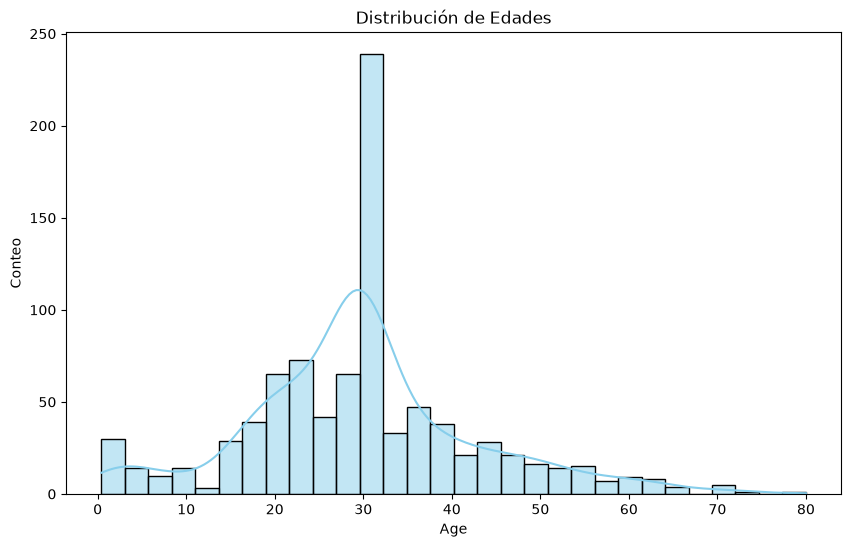

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribución de Edades')
plt.xlabel('Age')
plt.ylabel('Conteo')
plt.show()

## 4) Sobrevivientes por `Pclass`
Barplot del total de sobrevivientes por clase de pasajero.

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3199305076.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')
/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3199305076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')


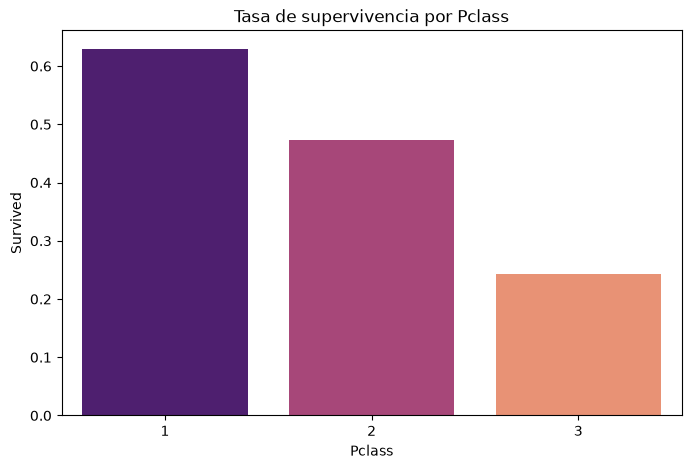

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=df, ci=None, palette='magma')
plt.title('Tasa de supervivencia por Pclass')
plt.show()

## 5) Sobrevivientes por `Sex`
Barplot de supervivencia por sexo.

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3248675556.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')
/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3248675556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')


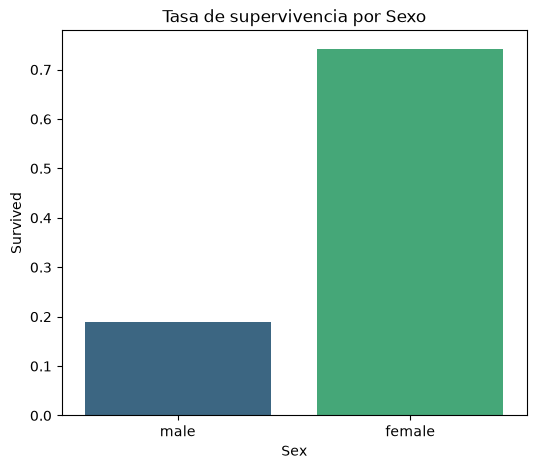

In [7]:
plt.figure(figsize=(6,5))
sns.barplot(x='Sex', y='Survived', data=df, ci=None, palette='viridis')
plt.title('Tasa de supervivencia por Sexo')
plt.show()

## 6) Sobrevivientes por `Embarked`
Barplot de supervivencia según puerto de embarque.

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/2584848680.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, ci=None, palette='cool')
/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/2584848680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, ci=None, palette='cool')


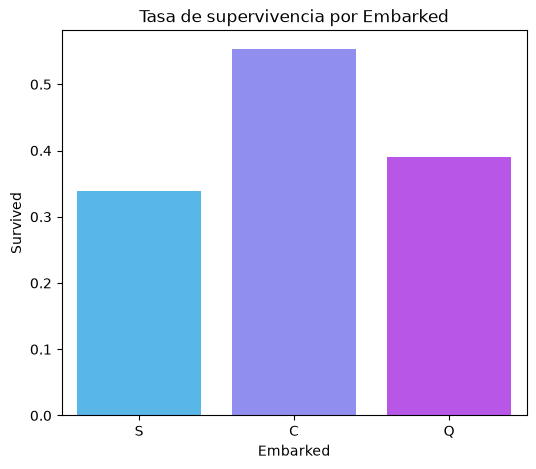

In [8]:
plt.figure(figsize=(6,5))
sns.barplot(x='Embarked', y='Survived', data=df, ci=None, palette='cool')
plt.title('Tasa de supervivencia por Embarked')
plt.show()

## 7) Agrupar `Age` en categorías y mostrar tasa de supervivencia
Categorías: Infante (0), Niño (1-12), Adolescente (13-17), Joven Adulto (18-25), Adulto (26-59), Mayor (60+).

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3247537860.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_survival.index, y=age_group_survival.values, palette='Spectral')


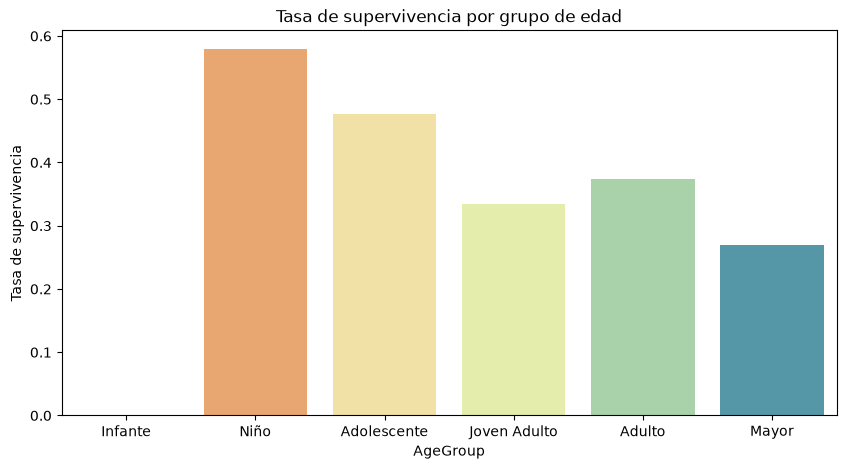

In [9]:
bins = [-1, 0, 12, 17, 25, 59, 200]
        
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_group_survival = df.groupby('AgeGroup')['Survived'].mean().reindex(labels)
plt.figure(figsize=(10,5))
sns.barplot(x=age_group_survival.index, y=age_group_survival.values, palette='Spectral')
plt.ylabel('Tasa de supervivencia')
plt.title('Tasa de supervivencia por grupo de edad')
plt.show()

## 8) Conteo de pasajeros por `Pclass`

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/1728841485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='pastel')


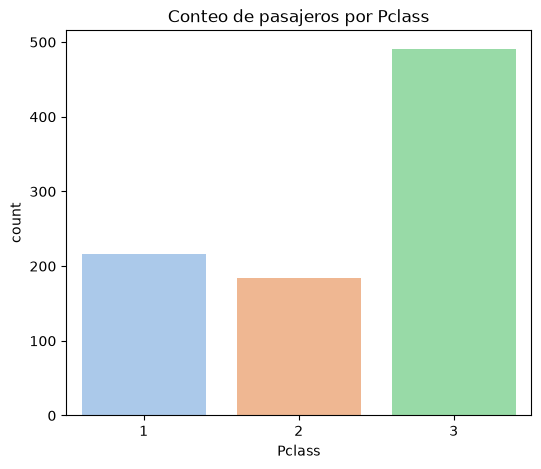

In [10]:
plt.figure(figsize=(6,5))
sns.countplot(x='Pclass', data=df, palette='pastel')
plt.title('Conteo de pasajeros por Pclass')
plt.show()

## 9) Distribución de `Sex` dentro de cada `Pclass`

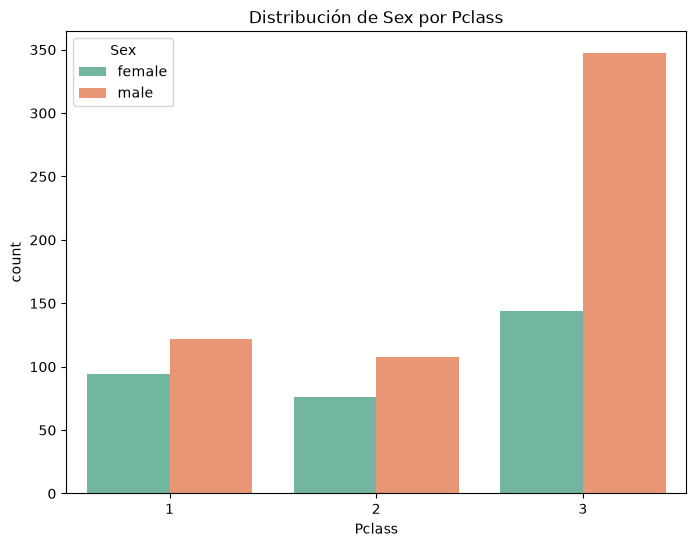

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass', hue='Sex', data=df, palette='Set2')
plt.title('Distribución de Sex por Pclass')
plt.show()

## 10) Distribución de `Pclass` según `Embarked`

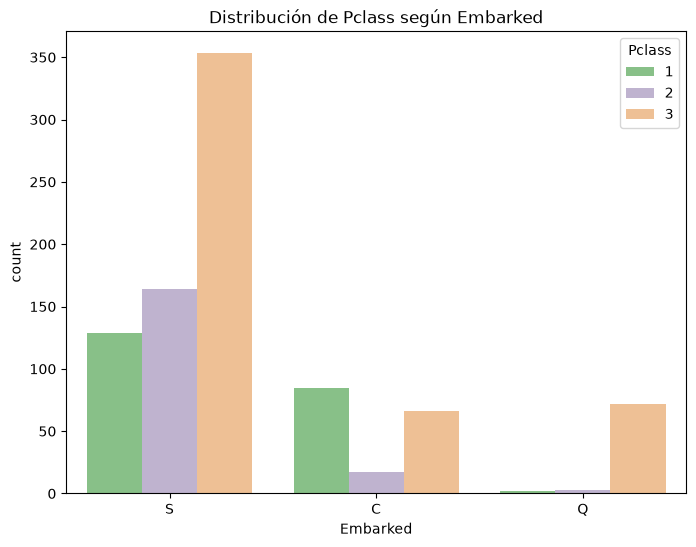

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(x='Embarked', hue='Pclass', data=df, palette='Accent')
plt.title('Distribución de Pclass según Embarked')
plt.show()

## 11) Conteo de pasajeros por `Sex`

/var/folders/98/6vd1dcln1135dknhfdnqg05r0000gn/T/ipykernel_53653/3568549041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='cool')


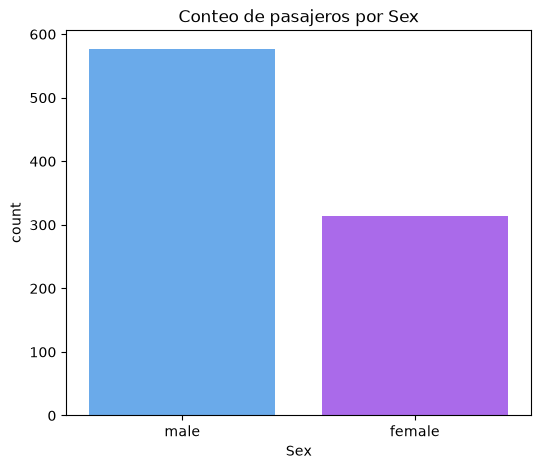

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sex', data=df, palette='cool')
plt.title('Conteo de pasajeros por Sex')
plt.show()

## 12) Valores mínimo y máximo de `Age`

In [14]:
df['Age'].min(), df['Age'].max()

(np.float64(0.42), np.float64(80.0))

## 13) Distribución de `Age` con media, mediana y moda
Se muestran líneas verticales indicando la media, mediana y moda.

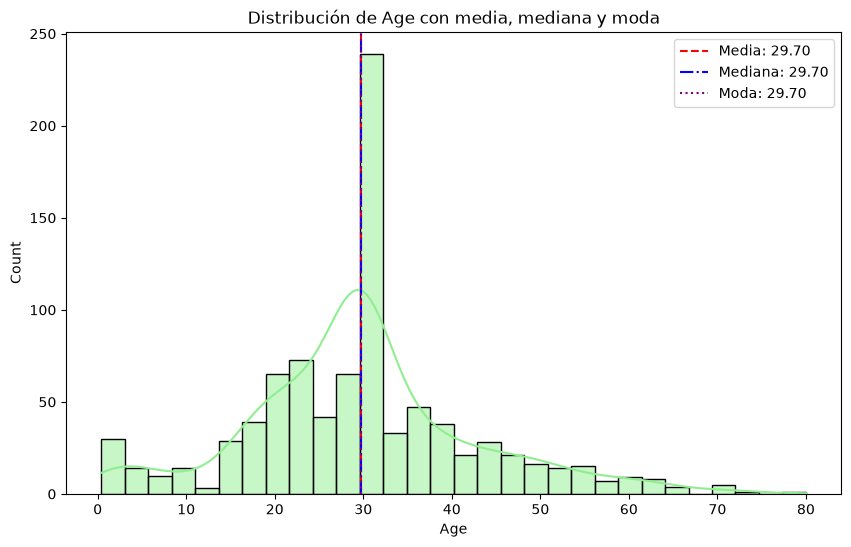

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='lightgreen')
mean_age = df['Age'].mean()
median_age = df['Age'].median()
mode_age = df['Age'].mode().iloc[0]
plt.axvline(mean_age, color='red', linestyle='--', label=f'Media: {mean_age:.2f}')
plt.axvline(median_age, color='blue', linestyle='-.', label=f'Mediana: {median_age:.2f}')
plt.axvline(mode_age, color='purple', linestyle=':', label=f'Moda: {mode_age:.2f}')
plt.legend()
plt.title('Distribución de Age con media, mediana y moda')
plt.show()

## 14) Boxplot de `Age`

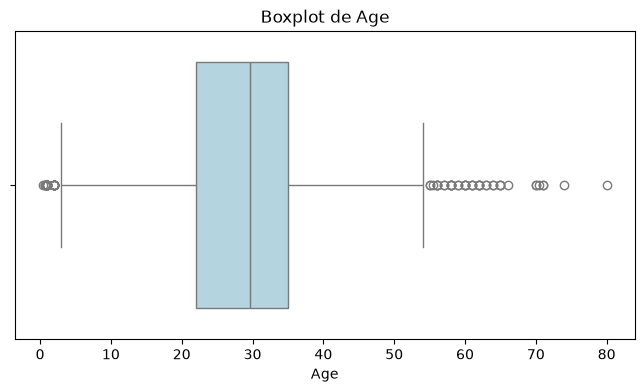

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'], color='lightblue')
plt.title('Boxplot de Age')
plt.show()

## 15) Valores mínimo y máximo de `Fare`

In [17]:
df['Fare'].min(), df['Fare'].max()

(np.float64(0.0), np.float64(512.3292))

## 16) Distribución de `Fare` con media, mediana y moda

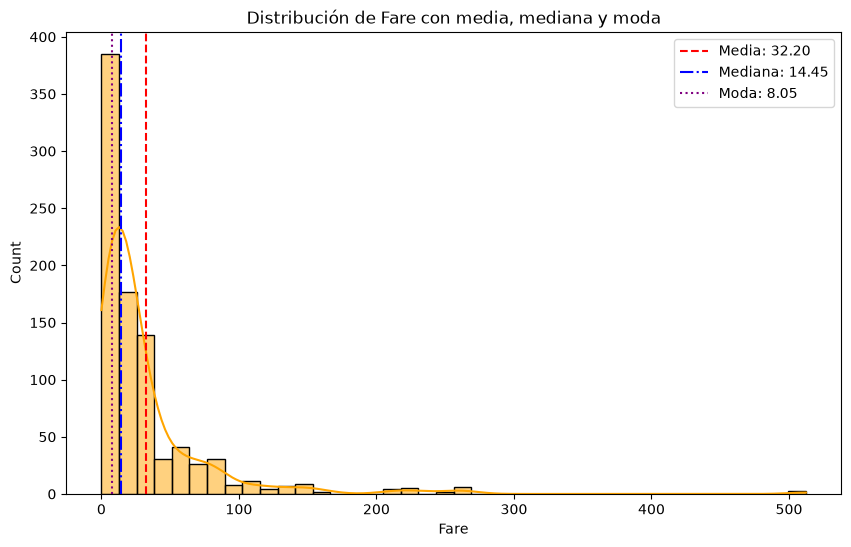

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['Fare'].dropna(), bins=40, kde=True, color='orange')
mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()
mode_fare = df['Fare'].mode().iloc[0]
plt.axvline(mean_fare, color='red', linestyle='--', label=f'Media: {mean_fare:.2f}')
plt.axvline(median_fare, color='blue', linestyle='-.', label=f'Mediana: {median_fare:.2f}')
plt.axvline(mode_fare, color='purple', linestyle=':', label=f'Moda: {mode_fare:.2f}')
plt.legend()
plt.title('Distribución de Fare con media, mediana y moda')
plt.show()

## 17) Boxplot de `Fare`

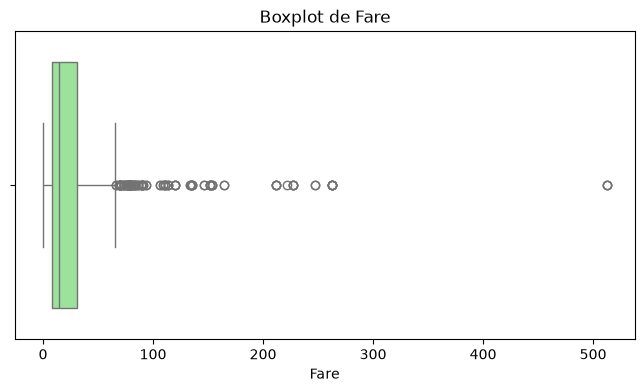

In [19]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'], color='lightgreen')
plt.title('Boxplot de Fare')
plt.show()

## 18) Pasajeros con `Fare` igual a 0
Filtrar y mostrar los registros cuyo fare es 0.

In [20]:
df[df['Fare'] == 0]
: 
,
: {
: 

: [
19

: 
,
: {
: 

: null,
: [],
: [
5
,
,
,

: 
,
: {
: 

: [
20

: 
,
: {
: 

: null,
: [],
: [
5
,
,
,

: 
,
: {
: 

: [
21

: 
,
: {
: 

: null,
: [],
: [
100
,

: 
,
: {
: 

: [
22
,

: 
,
: {
: 

: null,
: [],
: [
8
,
,
,
,
,

: {
: {
: 
,
: 
3

: {
: 
,
: 
3

: 4,
: 5

SyntaxError: invalid syntax (1254948249.py, line 2)